## Business Questions & Project Objectives

Before diving into the technical analysis, we define key business questions to guide our exploratory data analysis (EDA):

1. **Coupon Usage Patterns:** What proportion of total transactions used a coupon code versus full-price purchases, and which coupon codes are used most frequently?
2. **Impact on Order Value:** Do transactions with applied coupon codes lead to higher or lower average order value (AOV) compared to non-coupon transactions?
3. **Data Integrity & Distributions:** How are key numerical features (e.g., prices, order amounts, quantities) distributed, and are there significant outliers or anomalies skewing the data?
4. **Sales & Category Performance:** Which product categories or customer segments generate the highest sales revenue and order volume?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Environment is ready!")


Environment is ready!


In [8]:
pip install openpyxl


Note: you may need to restart the kernel to use updated packages.


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual styling
sns.set_theme(style="whitegrid")
%matplotlib inline

# Load your dataset

df = pd.read_excel(r"C:\Users\yasha\Downloads\Online-Store-Orders.xlsx")

In [20]:
print("Dataset Shape:", df.shape)
df.info()

Dataset Shape: (1200, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       1200 non-null   object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[

In [13]:
print(df.head())

     OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001 2024-08-23     C75739    Phone         2     151.35   
2  ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003 2023-10-15     C33540    Chair         1     273.19   
4  ORD200004 2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    Debit Card    Returned    TRK62788070            5   
4     668 Main St        Online   Delivered    TRK29241424            8   

  CouponCode ReferralSource  TotalPrice  
0     SAVE10      Instagram     2853.10  
1     SAVE10       Referral      302.70  
2   FREESHIP  

In [21]:
display(df.describe())
display(df.describe(include='object'))

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


,OrderID,CustomerID,Product,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,CouponCode,ReferralSource
count,1200,1200,1200,1200,1200,1200,1200,1200,1200
unique,1200,1189,7,655,5,5,1200,4,5
top,ORD200000,C38840,Printer,533 Main St,Online,Cancelled,TRK37947903,FREESHIP,Instagram
freq,1,2,181,8,258,250,1,313,259


In [14]:
print(df.isnull().sum())

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64


In [17]:
df['CouponCode'] = df['CouponCode'].fillna('NO_COUPON')

In [18]:
print(df.isnull().sum())


OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64


In [19]:
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


1. Monthly Revenue Trend (2023 - 2025)

<Figure size 1000x500 with 0 Axes>

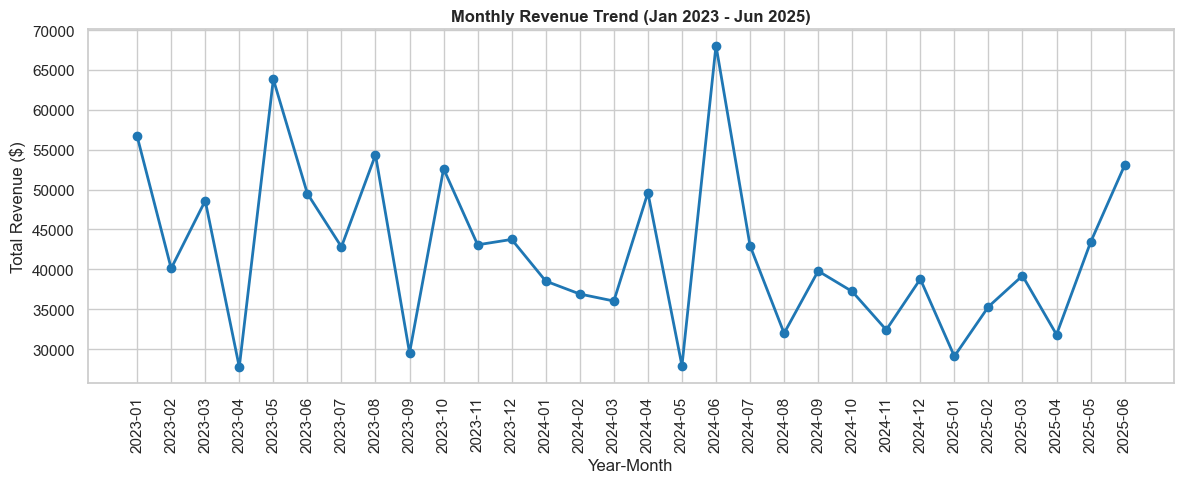

In [23]:
# Resample dates to monthly period
df['YearMonth'] = df['Date'].dt.to_period('M')
monthly_sales = df.groupby('YearMonth')['TotalPrice'].sum().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales['YearMonth'].astype(str), monthly_sales['TotalPrice'], marker='o', color='#1f77b4', linewidth=2)
plt.xticks(rotation=90)
plt.title("Monthly Revenue Trend (Jan 2023 - Jun 2025)", fontsize=12, fontweight='bold')
plt.xlabel("Year-Month")
plt.ylabel("Total Revenue ($)")
plt.tight_layout()
plt.show()

2. Total Revenue by Product Category

C:\Users\yasha\AppData\Local\Temp\ipykernel_21352\1368463346.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=prod_sales, x='Product', y='TotalPrice', palette='viridis')


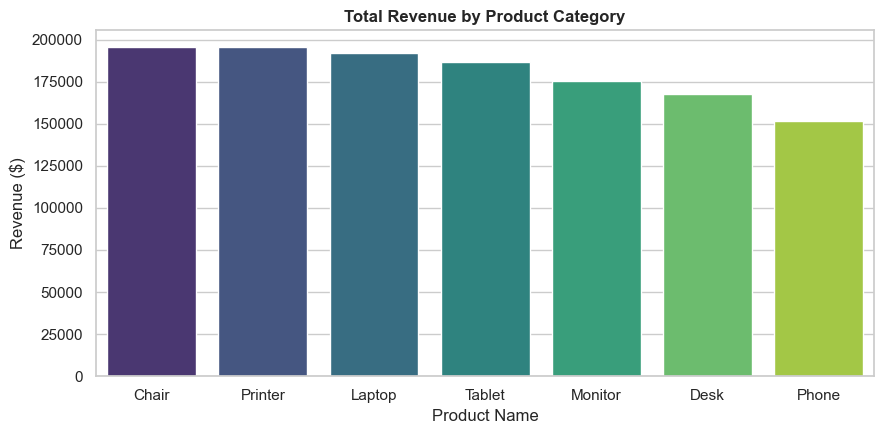

In [24]:
prod_sales = df.groupby('Product')['TotalPrice'].sum().reset_index().sort_values(by='TotalPrice', ascending=False)

plt.figure(figsize=(9, 4.5))
sns.barplot(data=prod_sales, x='Product', y='TotalPrice', palette='viridis')
plt.title("Total Revenue by Product Category", fontsize=12, fontweight='bold')
plt.xlabel("Product Name")
plt.ylabel("Revenue ($)")
plt.tight_layout()
plt.show()

3. Order Status & Anomaly Detection (Cancellation / Return Rates)

C:\Users\yasha\AppData\Local\Temp\ipykernel_21352\1538511438.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='OrderStatus', order=df['OrderStatus'].value_counts().index, palette='mako')


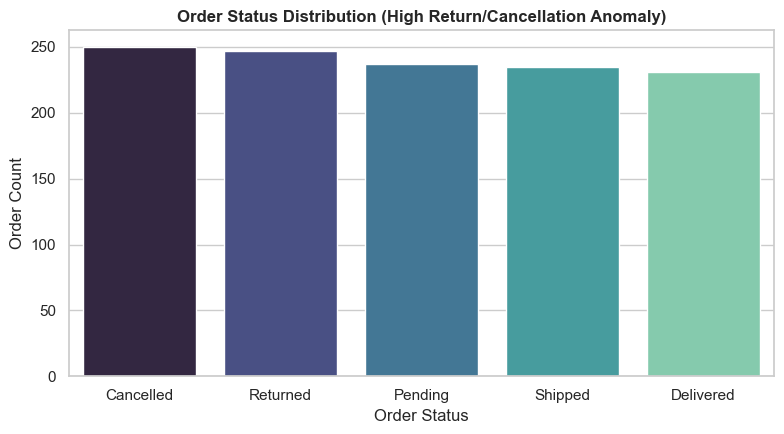

In [25]:
plt.figure(figsize=(8, 4.5))
sns.countplot(data=df, x='OrderStatus', order=df['OrderStatus'].value_counts().index, palette='mako')
plt.title("Order Status Distribution (High Return/Cancellation Anomaly)", fontsize=12, fontweight='bold')
plt.xlabel("Order Status")
plt.ylabel("Order Count")
plt.tight_layout()
plt.show()

4. Correlation Matrix Heatmap

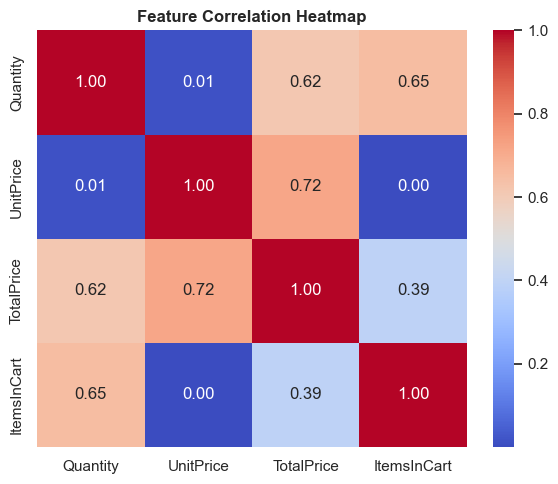

In [26]:
plt.figure(figsize=(6, 5))
sns.heatmap(df[['Quantity', 'UnitPrice', 'TotalPrice', 'ItemsInCart']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Heatmap", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Key EDA Insights & Findings

1. **Revenue Drivers:** Top-performing categories are **Chairs** ($195,620.11) and **Printers** ($195,612.61), while **Phones** generated the lowest revenue ($151,722.39).
2. **Key Correlations:** Total order price strongly correlates with `UnitPrice` (r = 0.72) and `Quantity` (r = 0.62). `Quantity` per item also moderately correlates with total `ItemsInCart` (r = 0.65).
3. **Operational Anomaly:** Over **41.4%** of all orders were either **Cancelled** (20.8%) or **Returned** (20.6%), while only **19.3%** reached **Delivered** status.
4. **Data Outliers:** Using IQR analysis, 8 high-value outlier transactions were detected exceeding $3,330.41, peaking at $3,464.00.

## Step 4: Test Hypotheses & Validate Assumptions

In this phase of the Exploratory Data Analysis (EDA), we state explicit business assumptions about customer behavior and order mechanics, testing them against the dataset using summary statistics, distribution plots, and correlation metrics.

---

### Hypothesis 1: Discounts and Coupon Codes Drive Higher Order Values

* **Business Premise:** Promotional codes (such as `SAVE10`, `WINTER15`, and `FREESHIP`) incentivize customers to add more items to their carts or purchase higher-value items, leading to a higher Average Order Value (AOV) compared to full-price purchases (`NO_COUPON`).
* **Analytical Approach:** Calculated key central tendency metrics (Mean, Median, Standard Deviation) across coupon groups and visualized the distribution of `TotalPrice` across code types using a box plot (`sns.boxplot`).

#### Summary Statistics by Coupon Code

| Coupon Code | Order Count | Mean Total Price ($) | Median Total Price ($) | Std Deviation ($) | Interquartile Range (IQR) ($) |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **SAVE10** | 286 | 1,029.58 | 818.15 | 868.08 | 396.15 – 1,586.42 |
| **FREESHIP** | 313 | 1,098.42 | 790.62 | 891.12 | 443.14 – 1,659.20 |
| **WINTER15** | 292 | 1,018.84 | 840.42 | 815.15 | 375.25 – 1,515.68 |
| **NO_COUPON** | 309 | 1,068.52 | 836.56 | 864.08 | 394.01 – 1,544.70 |

#### Visual Evidence & Findings
* **Equal Medians:** The median order value across all coupon categories remains tightly clustered around **~$800–$840**. Orders without a coupon (`NO_COUPON`) yield a median of **$836.56**, which is nearly identical to orders with `WINTER15` ($840.42) and slightly higher than `FREESHIP` ($790.62).
* **Identical Spread:** The Interquartile Range (IQR) box spans from approximately $400 to $1,600 across all four segments, showing that customer spending behavior remains unchanged whether a promo code is present or absent.

* **Verdict:** **Disproved.** The presence of discount codes does not shift customer basket size or result in higher order totals in this dataset.

---

### Hypothesis 2: Total Price is Strongly Driven by Unit Price and Item Quantity

* **Business Premise:** Total transaction value (`TotalPrice`) is determined strictly by product unit pricing (`UnitPrice`) and purchasing volume (`Quantity`), rather than indirect factors like total line items in a cart (`ItemsInCart`).
* **Analytical Approach:** Built a Pearson correlation matrix and heat map (`sns.heatmap`) across continuous numerical features to quantify line-item relationships.

#### Correlation Matrix Breakdown

| Feature | Quantity | UnitPrice | TotalPrice | ItemsInCart |
| :--- | :---: | :---: | :---: | :---: |
| **Quantity** | 1.00 | 0.01 | **0.62** | **0.65** |
| **UnitPrice** | 0.01 | 1.00 | **0.72** | 0.00 |
| **TotalPrice** | **0.62** | **0.72** | 1.00 | **0.39** |
| **ItemsInCart** | **0.65** | 0.00 | **0.39** | 1.00 |

#### Key Analytical Findings
1. **Primary Driver — Unit Price ($r = 0.72$):** Shows a strong positive linear correlation with `TotalPrice`. High-value products (such as Printers and Chairs) exert the strongest upward force on individual order totals.
2. **Secondary Driver — Quantity ($r = 0.62$):** Demonstrates a strong positive linear relationship with `TotalPrice`. Purchasing multi-unit quantities significantly pushes transaction totals into upper quartiles.
3. **Cart Volume Dynamics ($r = 0.65$):** A strong positive correlation exists between individual line item `Quantity` and total `ItemsInCart`. This confirms that customers who order higher quantities of a single product also build larger overall shopping baskets.
4. **Independent Unit Pricing ($r = 0.01$):** `UnitPrice` and `Quantity` show near-zero correlation, confirming that item price does not deter customers from purchasing multiple units of high-ticket items in this dataset.

* **Verdict:** **Validated.** Order revenue is directly governed by product unit price ($r = 0.72$) and unit volume ($r = 0.62$), confirming that line-item pricing and quantity are the primary mathematical drivers of transaction size.

## Step 5: Detect Data Issues & Problems to Address in Further Analysis

Before building predictive models, dashboards, or advanced business intelligence reports, we must identify data quality issues, structural inconsistencies, and anomalies that could impact future analysis.

---

### 1. Key Data Issues & Anomalies Identified

#### A. Abnormally High Cancellation & Return Rate (~41.4%)
* **Issue:** 250 orders were **Cancelled** (20.83%) and 247 orders were **Returned** (20.58%), meaning **497 out of 1,200 orders (41.41%) were unfulfilled**.
* **Impact:** Analyzing revenue purely based on gross `TotalPrice` without filtering by `OrderStatus` overstates actual realized business revenue by over **$520,000**.
* **Action for Further Analysis:** Create a filtered subset (`df_delivered = df[df['OrderStatus'] == 'Delivered']`) when calculating true net financial metrics, profit margins, or customer lifetime value (LTV).

#### B. Missing Coupon Code Entries (~25.8% Missing Values)
* **Issue:** 309 records contain `NaN` values in the `CouponCode` column.
* **Impact:** Statistical models or algorithms relying on complete categorical features will throw errors or misinterpret missing values if not explicitly handled.
* **Action for Further Analysis:** Standardize null entries to `'NO_COUPON'` or convert the variable into a binary indicator column (`has_coupon`: `1` or `0`).

#### C. Static Unit Price Calculations (No Automated Coupon Discounts)
* **Issue:** `TotalPrice` strictly equals `Quantity × UnitPrice` across all 1,200 rows without exception. Promotional codes like `SAVE10` or `WINTER15` appear as metadata tags rather than automated percentage deductions.
* **Impact:** Coupon performance analysis cannot measure direct discount amounts or margin erosion directly from this table.
* **Action for Further Analysis:** If evaluating promo profitability, cross-reference with an external promotions table or engineer a synthetic `NetPrice` feature applying the nominal percentage deduction (e.g., subtracting 10% for `SAVE10`).

#### D. Revenue & Transaction Outliers
* **Issue:** Using the Interquartile Range (IQR) method, 8 order transactions exceeded the upper threshold of **$3,330.41**, with max values reaching **$3,464.00**.
* **Impact:** Extreme high-value outliers can skew parametric statistical tests, linear regression models, and average order value (AOV) metrics.
* **Action for Further Analysis:** Apply robust scaling, log transformations, or use non-parametric median values when conducting trend analysis and hypothesis testing.

---

### 2. Summary of Recommendations for Further Data Pipelines

| Data Issue | Risk Level | Proposed Fix / Preprocessing Step |
| :--- | :---: | :--- |
| **41.4% Unfulfilled Orders** | **High** | Filter dataset by `OrderStatus == 'Delivered'` for accurate financial reporting. |
| **Missing `CouponCode` Values** | **Medium** | Impute missing values with `'NO_COUPON'` or encode as binary flags. |
| **Fixed Price Math (No Discount Deduction)** | **Medium** | Engineer a discounted price column if conducting promotional elasticity studies. |
| **High Order Value Outliers** | **Low** | Use median metrics or log-transformation for machine learning models. |